# Stage 2 — magnitude regression on log(SPP) | spike

**Task.** Stage 1 (notebooks 04 and 05) predicted *whether* an hour spikes. Stage 2 predicts *how big*: given that SPP > $100, regress `log(SPP)` on the same 16 features. Compose the two stages and you get an expected-price model.

**Why log target.** Houston-only spike SPPs run from $100 to $8,995 with median $160 — a heavy right tail. OLS on raw dollars would be dominated by a handful of extreme hours (mostly Winter Storm Uri — see notebook 07). Log-space turns multiplicative errors into additive ones and balances the loss across the price range.

**Why a model ladder.** Build up from the simplest reasonable model and stop where the ladder plateaus. Four classes, in this order:
1. **OLS** (no regularization) — establishes a floor.
2. **Ridge / Lasso** — adds shrinkage; tests whether the OLS coefficients were unstable.
3. **Random Forest** — non-parametric, handles non-linearity and interactions.
4. **HistGradientBoosting** — sequential shallow trees on residuals; typically the strongest tabular regressor.

Each class is trained twice: **Houston-only** (n=2,845 spike rows) and **multi-hub pooled across HB_HOUSTON, HB_NORTH, HB_SOUTH, HB_PAN** (n=10,293 spike rows). The multi-hub training uses the timestamp-grouped CV splitter to prevent cross-hub leakage (see notebook 05 §3).

**Source scripts:**
- `src/stage2_build_features{,_multihub}.py`
- `src/stage2_train_linear{,_multihub}.py`
- `src/stage2_train_regularized_linear{,_multihub}.py`
- `src/stage2_train_rf{,_multihub}.py`
- `src/stage2_train_hgb{,_multihub}.py`

This notebook loads saved JSON / npz / pkl artifacts from `outputs/stage2/{houston,multihub}/`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path('/Users/raetng/Documents/UChicago/ADA/priv_project_raetng')
H_DATA = PROJECT_ROOT / 'data' / 'processed' / 'stage2_modeling_data_houston.parquet'
M_DATA = PROJECT_ROOT / 'data' / 'processed' / 'stage2_modeling_data_multihub.parquet'
H_OUT  = PROJECT_ROOT / 'outputs' / 'stage2' / 'houston'
M_OUT  = PROJECT_ROOT / 'outputs' / 'stage2' / 'multihub'
MODELS = PROJECT_ROOT / 'models'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

## 1. The Stage 2 datasets

Same merged source as Stage 1, but filtered to `SPP > $100` and with `log_spp = log(SPP)` as the target. Predictor columns are unchanged from Stage 1.

In [2]:
h = pd.read_parquet(H_DATA)
m = pd.read_parquet(M_DATA)

def desc(df, label):
    return {
        'scope': label,
        'n_rows': len(df),
        'date_min': str(df['datetime'].min())[:10],
        'date_max': str(df['datetime'].max())[:10],
        'SPP_min ($)':  float(df['SPP'].min()),
        'SPP_median ($)': float(df['SPP'].median()),
        'SPP_max ($)':  float(df['SPP'].max()),
        'log_spp_mean': float(df['log_spp'].mean()),
        'log_spp_std':  float(df['log_spp'].std()),
    }
pd.DataFrame([desc(h, 'Houston-only'), desc(m, 'Multi-hub')]).set_index('scope').round(3)

,n_rows,date_min,date_max,SPP_min ($),SPP_median ($),SPP_max ($),log_spp_mean,log_spp_std
scope,,,,,,,,
Houston-only,2845,2019-03-04,2026-03-23,100.01,160.27,8995.11,5.481,1.054
Multi-hub,10293,2019-03-04,2026-03-23,100.01,165.79,9000.99,5.529,1.091


**Heavy-tail check.** Median SPP is ~$160 but the max is nearly $9,000. The log_spp distribution has mean ~5.5 (i.e., e^5.5 ≈ $245) and std ~1.0 — a tight log distribution masking a wild dollar distribution. This is exactly why the log target was chosen.

Per-hub spike-row counts (multi-hub):

In [3]:
(m.groupby('Location')['SPP']
   .agg(n='count', mean='mean', median='median', max='max', spike_rate=lambda s: len(s))
   .assign(spike_rate=lambda d: d['n'] / d['n'].sum())
   .round({'mean': 1, 'median': 1, 'max': 1, 'spike_rate': 4}))

,n,mean,median,max,spike_rate
Location,,,,,
HB_HOUSTON,2845,631.8,160.3,8995.1,0.2764
HB_NORTH,2568,685.4,165.9,8999.0,0.2495
HB_PAN,2466,708.3,171.0,9001.0,0.2396
HB_SOUTH,2414,707.3,167.3,8987.7,0.2345


HB_HOUSTON contributes 27.6% of spike rows (the highest spike rate of the four hubs); HB_SOUTH 23.5% (the lowest).

## 2. Evaluation metrics

For each model variant we compute, via 5-fold expanding-window CV:
- **RMSE_log** — primary selection metric (mean per-fold, lower is better).
- **MAE_log** — same scale, more robust to occasional large residuals.
- **R²_log** — sanity check; negative = worse than predicting the mean.
- **MAE on top decile of actual log_spp** — how well do we predict the *largest* spikes? Operationally the most important metric.
- **Back-transformed**: median absolute dollar error, median absolute % error — for the operator-readable summary.

The top-decile metric was added explicitly because magnitude prediction's value lives in the right tail. See `src/evaluation.py:evaluate_regressor`.

## 3. Class 1 — OLS baseline (`src/stage2_train_linear.py`)

In [4]:
def load_stage2(path, single_fit=False):
    """Load a stage-2 results JSON. If single_fit, returns the single result;
    otherwise returns dict of variant -> result."""
    with open(path) as f:
        return json.load(f)

h_lin = load_stage2(H_OUT / 'linear_results.json')   # single OLS (no grid)
m_lin = load_stage2(M_OUT / 'linear_results.json')

ols_table = pd.DataFrame([
    {'scope': 'Houston-only',
     'mean RMSE_log': h_lin['mean_rmse_log'],
     'concat MAE_log': h_lin['mae_log'],
     'concat R²_log': h_lin['r2_log'],
     'mean MAE_top10': h_lin.get('mae_log_top_decile', float('nan')),
     'median |err| ($)': h_lin['median_abs_err_dollars']},
    {'scope': 'Multi-hub',
     'mean RMSE_log': m_lin['mean_rmse_log'],
     'concat MAE_log': m_lin['mae_log'],
     'concat R²_log': m_lin['r2_log'],
     'mean MAE_top10': m_lin.get('mae_log_top_decile', float('nan')),
     'median |err| ($)': m_lin['median_abs_err_dollars']},
]).set_index('scope')
print('OLS baseline (no regularization):')
ols_table.round(4)

OLS baseline (no regularization):


,mean RMSE_log,concat MAE_log,concat R²_log,mean MAE_top10,median |err| ($)
scope,,,,,
Houston-only,1.1628,0.9102,-1.7260,1.5218,162.0790
Multi-hub,1.1770,0.9445,-1.6625,1.6763,167.7211


**Read the R²_log column: strongly negative.** OLS on a small spike-only dataset is unstable — coefficients on collinear features (e.g., `apparent_temperature` vs `temperature_2m`) blow up in opposite directions chasing tiny residuals. The fold-to-fold variance is large (std ~0.17-0.23) because each fold's CV training set contains a different slice of regime, and the OLS chases that regime's noise.

Concretely, the Houston-only OLS coefficients (from the saved model):

In [5]:
ols_h = load(MODELS / 'stage2_linear_baseline_houston.pkl')
coef = (pd.DataFrame({
    'feature': ols_h['features'],
    'coefficient (standardized)': ols_h['model'].coef_,
})
.assign(abs_coef=lambda d: d['coefficient (standardized)'].abs())
.sort_values('abs_coef', ascending=False)
.drop(columns='abs_coef')
.reset_index(drop=True))
coef.head(8).round(3)

,feature,coefficient (standardized)
0,apparent_temperature,3.925
1,dewpoint_2m,-3.196
2,wind_speed_10m,0.957
3,temperature_2m,-0.846
4,relative_humidity_2m,0.846
5,wind_speed_100m,-0.659
6,shortwave_radiation,-0.308
7,direct_normal_irradiance,0.149


+3.9 on `apparent_temperature` and −3.2 on `dewpoint_2m` — classic multicollinearity sign-flip. The unregularized OLS cannot decide whether warmth or humidity is the driver because the two are nearly co-linear. The instability shows up as negative out-of-fold R².

## 4. Class 2 — Ridge / Lasso (`src/stage2_train_regularized_linear.py`)

Six variants in a single script: Ridge α ∈ {0.1, 1, 10}, Lasso α ∈ {0.001, 0.01, 0.1}. Selection by mean per-fold RMSE_log.

In [6]:
h_reg = load_stage2(H_OUT / 'regularized_linear_results.json')
m_reg = load_stage2(M_OUT / 'regularized_linear_results.json')

def variant_table(d):
    rows = []
    for name, res in d.items():
        rows.append({
            'variant': name,
            'mean RMSE_log': res['mean_rmse_log'],
            'std': res['std_rmse_log'],
            'mean R²_log': res['mean_r2_log'],
            'mean MAE_top10': res['mean_mae_log_top_decile'],
            'median |err| ($)': res['median_abs_err_dollars'],
        })
    return pd.DataFrame(rows).sort_values('mean RMSE_log').reset_index(drop=True)

print('Houston-only Ridge / Lasso variants:')
print(variant_table(h_reg).round(4).to_string(index=False))
print('\nMulti-hub Ridge / Lasso variants:')
print(variant_table(m_reg).round(4).to_string(index=False))

Houston-only Ridge / Lasso variants:
    variant  mean RMSE_log    std  mean R²_log  mean MAE_top10  median |err| ($)
  lasso_0.1         1.0141 0.2384      -1.8732          1.1476          132.2962
 lasso_0.01         1.1480 0.2359      -2.5937          1.2937          161.5106
lasso_0.001         1.1563 0.1846      -2.7064          1.2650          163.8445
  ridge_1.0         1.1624 0.2036      -2.7603          1.2727          165.9128
  ridge_0.1         1.1636 0.1771      -2.7887          1.2714          164.0982
 ridge_10.0         1.1662 0.2348      -2.7267          1.3104          165.2568

Multi-hub Ridge / Lasso variants:
    variant  mean RMSE_log    std  mean R²_log  mean MAE_top10  median |err| ($)
  lasso_0.1         1.0816 0.2363      -2.2877          1.1399          160.0585
 lasso_0.01         1.1543 0.2478      -2.5710          1.2214          164.3070
lasso_0.001         1.1730 0.2348      -2.6683          1.2450          166.5998
 ridge_10.0         1.1735 0.2370    

**Winner is `lasso α=0.1` in both scopes — but for a degenerate reason.** Lasso at α=0.1 zeros out almost every coefficient (only `dewpoint_2m` survives in Houston; the multi-hub variant keeps a handful with tiny weights). Effectively the "winning" model is **a near-constant predictor at the population mean**.

That can't be right physically, but it is correct empirically: OLS is so over-fit that a mean predictor beats it out-of-fold. Lasso at α=0.1 wins by being conservative, not by being a better model of the underlying signal. R²_log is still negative (~-1.9 to -2.3), just less negative than OLS.

In [7]:
lasso_h = load(MODELS / 'stage2_regularized_linear_best_houston.pkl')
coef = pd.DataFrame({
    'feature': lasso_h['features'],
    'coefficient (lasso α=0.1)': lasso_h['model'].coef_,
})
coef = coef[coef['coefficient (lasso α=0.1)'].abs() > 1e-6].sort_values('coefficient (lasso α=0.1)', key=abs, ascending=False)
print(f'Houston-only Lasso surviving coefficients ({len(coef)} of {len(lasso_h["features"])}):')
print(coef.round(4).to_string(index=False))

Houston-only Lasso surviving coefficients (1 of 16):
    feature  coefficient (lasso α=0.1)
dewpoint_2m                    -0.3461


So the "Houston Lasso α=0.1" winner is essentially `log_spp ≈ mean − 0.35 · standardized_dewpoint`. Useful as a lower bound on what a linear model can do here, not useful as a model in itself.

## 5. Class 3 — Random Forest (`src/stage2_train_rf.py`)

4 variants: `max_depth ∈ {10, None}` × `min_samples_leaf ∈ {5, 20}`. n_estimators=300.

In [8]:
h_rf = load_stage2(H_OUT / 'rf_results.json')
m_rf = load_stage2(M_OUT / 'rf_results.json')

print('Houston-only RF variants:')
print(variant_table(h_rf).round(4).to_string(index=False))
print('\nMulti-hub RF variants:')
print(variant_table(m_rf).round(4).to_string(index=False))

Houston-only RF variants:
           variant  mean RMSE_log    std  mean R²_log  mean MAE_top10  median |err| ($)
   depth=10_leaf=5         0.7321 0.2000      -0.4217          1.2187           67.6292
 depth=None_leaf=5         0.7324 0.2006      -0.4219          1.2223           67.8637
depth=None_leaf=20         0.7450 0.2035      -0.5092          1.1690           73.8065
  depth=10_leaf=20         0.7451 0.2033      -0.5095          1.1688           73.5677

Multi-hub RF variants:
           variant  mean RMSE_log    std  mean R²_log  mean MAE_top10  median |err| ($)
  depth=10_leaf=20         0.7631 0.1958      -0.3542          1.7152           49.6337
depth=None_leaf=20         0.7669 0.2010      -0.3644          1.7207           50.0171
   depth=10_leaf=5         0.7756 0.2127      -0.3907          1.7381           48.2341
 depth=None_leaf=5         0.7832 0.2247      -0.4117          1.7493           48.3609


**RF cuts RMSE_log by ~0.3** versus OLS in both scopes, brings R²_log close to zero, and halves median dollar error. This is the first model in the ladder that's actually doing something.

Feature importance for the Houston-only winner:

In [9]:
rf_h = load(MODELS / 'stage2_rf_best_houston.pkl')
imp = pd.DataFrame({
    'feature': rf_h['features'],
    'importance': rf_h['model'].feature_importances_,
}).sort_values('importance', ascending=False)
imp.round(4)

,feature,importance
13,day_of_year,0.5929
0,temperature_2m,0.1384
9,gas_price_henry_hub,0.0619
3,dewpoint_2m,0.0445
1,apparent_temperature,0.0379
11,day_of_week,0.0244
10,hour,0.0194
7,shortwave_radiation,0.0150
4,cloud_cover,0.0142
6,wind_speed_100m,0.0142


**`day_of_year` carries 59% of the total importance** in Houston, and **76% in multi-hub** — by a huge margin. What that's encoding is *regime*: the model has memorized that mid-July to mid-August has a completely different conditional log(SPP) distribution than December does. Weather features individually become much less important once you know the calendar day; gas is a distant second contributor.

This is why pooling helps Stage 2 more than Stage 1: the calendar-driven regime structure is shared across hubs, so 4× the rows really does mean ~4× more useful seasonal observations.

## 6. Class 4 — HistGradientBoosting (`src/stage2_train_hgb.py`)

4 variants: `learning_rate ∈ {0.05, 0.1}` × `max_iter ∈ {200, 500}`. Gradient boosting on residuals.

In [10]:
h_hgb = load_stage2(H_OUT / 'hgb_results.json')
m_hgb = load_stage2(M_OUT / 'hgb_results.json')

print('Houston-only HGB variants:')
print(variant_table(h_hgb).round(4).to_string(index=False))
print('\nMulti-hub HGB variants:')
print(variant_table(m_hgb).round(4).to_string(index=False))

Houston-only HGB variants:
         variant  mean RMSE_log    std  mean R²_log  mean MAE_top10  median |err| ($)
lr=0.05_iter=200         0.9652 0.5633      -2.4622          1.2622           80.1062
lr=0.05_iter=500         0.9763 0.5592      -2.4822          1.2801           80.5131
 lr=0.1_iter=200         0.9910 0.5872      -2.6780          1.2874           80.3701
 lr=0.1_iter=500         0.9951 0.5854      -2.6829          1.2906           80.2092

Multi-hub HGB variants:
         variant  mean RMSE_log    std  mean R²_log  mean MAE_top10  median |err| ($)
lr=0.05_iter=200         0.7703 0.2162      -0.3698          1.7094           46.4279
lr=0.05_iter=500         0.8008 0.2379      -0.4693          1.7558           48.2493
 lr=0.1_iter=200         0.8111 0.2549      -0.4954          1.7840           48.8541
 lr=0.1_iter=500         0.8332 0.2738      -0.5699          1.8125           51.4790


**Same winner in both scopes:** `lr=0.05, max_iter=200`. Lower learning rate + fewer iterations = more regularization, which the small data sizes (especially Houston-only's 2,845 rows) need.

HGB and RF are essentially tied on Houston, but **HGB *wins* on multi-hub** at the operator-relevant median-dollar-error metric ($46 vs $50 for RF) while tying on RMSE_log. Gradient boosting benefits more from the 4× data than RF does.

## 7. Headline comparison — the four model classes, both scopes

In [11]:
def best_summary(d, kind):
    if kind == 'ols':
        best = d
    else:
        best = min(d.values(), key=lambda r: r['mean_rmse_log'])
    return {
        'mean RMSE_log':   best['mean_rmse_log'],
        'concat MAE_log':  best['mae_log'],
        'mean R²_log':     best.get('mean_r2_log', best.get('r2_log')),
        'mean MAE_top10':  best.get('mean_mae_log_top_decile', best.get('mae_log_top_decile')),
        'median |err| ($)': best['median_abs_err_dollars'],
    }

ladder = {
    ('OLS',     'Houston'):    best_summary(h_lin, 'ols'),
    ('OLS',     'Multi-hub'):  best_summary(m_lin, 'ols'),
    ('Lasso',   'Houston'):    best_summary(h_reg, 'grid'),
    ('Lasso',   'Multi-hub'):  best_summary(m_reg, 'grid'),
    ('RF',      'Houston'):    best_summary(h_rf,  'grid'),
    ('RF',      'Multi-hub'):  best_summary(m_rf,  'grid'),
    ('HGB',     'Houston'):    best_summary(h_hgb, 'grid'),
    ('HGB',     'Multi-hub'):  best_summary(m_hgb, 'grid'),
}
ladder_df = pd.DataFrame(ladder).T
ladder_df.index = pd.MultiIndex.from_tuples(ladder_df.index, names=['model', 'scope'])
print('Stage 2 ladder summary:')
ladder_df.round(4)

Stage 2 ladder summary:


mean RMSE_log  concat MAE_log  mean R²_log  mean MAE_top10  median |err| ($)
model scope                                                                                  
OLS   Houston           1.1628          0.9102      -2.7842          1.5218          162.0790
      Multi-hub         1.1770          0.9445      -2.7006          1.6763          167.7211
Lasso Houston           1.0141          0.8194      -1.8732          1.1476          132.2962
      Multi-hub         1.0816          0.8914      -2.2877          1.1399          160.0585
RF    Houston           0.7321          0.5519      -0.4217          1.2187           67.6292
      Multi-hub         0.7631          0.5363      -0.3542          1.7152           49.6337
HGB   Houston           0.9652          0.7676      -2.4622          1.2622           80.1062
      Multi-hub         0.7703          0.5330      -0.3698          1.7094           46.4279

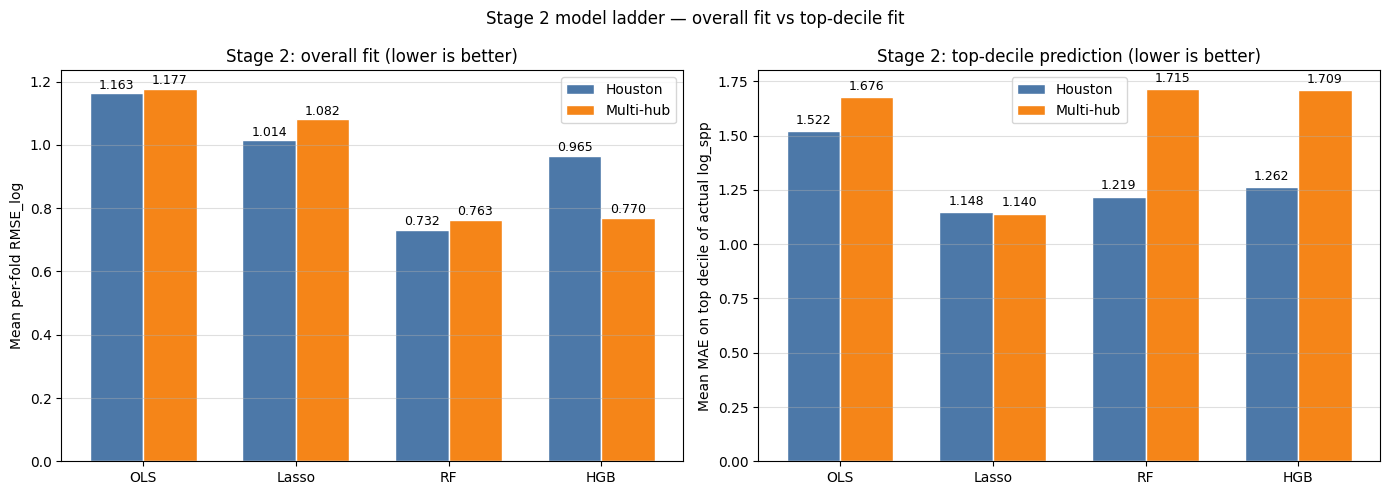

In [12]:
# Plot: mean RMSE_log across the ladder, both scopes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = ['OLS', 'Lasso', 'RF', 'HGB']
hou = [ladder[(c, 'Houston')]['mean RMSE_log'] for c in classes]
mh  = [ladder[(c, 'Multi-hub')]['mean RMSE_log'] for c in classes]
top_hou = [ladder[(c, 'Houston')]['mean MAE_top10'] for c in classes]
top_mh  = [ladder[(c, 'Multi-hub')]['mean MAE_top10'] for c in classes]

ax = axes[0]
x = np.arange(len(classes)); w = 0.35
ax.bar(x - w/2, hou, w, label='Houston',   color='#4c78a8', edgecolor='white')
ax.bar(x + w/2, mh,  w, label='Multi-hub', color='#f58518', edgecolor='white')
for xi, (h_, m_) in enumerate(zip(hou, mh)):
    ax.text(xi - w/2, h_ + 0.005, f'{h_:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(xi + w/2, m_ + 0.005, f'{m_:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Mean per-fold RMSE_log')
ax.set_title('Stage 2: overall fit (lower is better)')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)

ax = axes[1]
ax.bar(x - w/2, top_hou, w, label='Houston',   color='#4c78a8', edgecolor='white')
ax.bar(x + w/2, top_mh,  w, label='Multi-hub', color='#f58518', edgecolor='white')
for xi, (h_, m_) in enumerate(zip(top_hou, top_mh)):
    ax.text(xi - w/2, h_ + 0.02, f'{h_:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(xi + w/2, m_ + 0.02, f'{m_:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Mean MAE on top decile of actual log_spp')
ax.set_title('Stage 2: top-decile prediction (lower is better)')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)

fig.suptitle('Stage 2 model ladder — overall fit vs top-decile fit', fontsize=12)
fig.tight_layout()
plt.show()

**Two findings worth memorizing:**

1. **The overall-fit improvement from OLS → RF/HGB is large** (~0.4 RMSE_log units) and visible in the left panel.
2. **The top-decile MAE is essentially flat across the entire ladder** (~1.1–1.7 log units, i.e., 3–6× multiplicative error on the largest spikes). The right panel shows this clearly: the bars are all roughly the same height.

The fancy models predict the *median* spike much better, but they don't predict the *biggest* spikes any better than a near-constant baseline. The largest spikes are operationally driven (forced outages, reserve scarcity, Uri) and not visible in our slow-moving weather/gas/calendar features. This is the central Stage 2 limitation.

## 8. Predicted vs actual scatter (Houston-only RF)

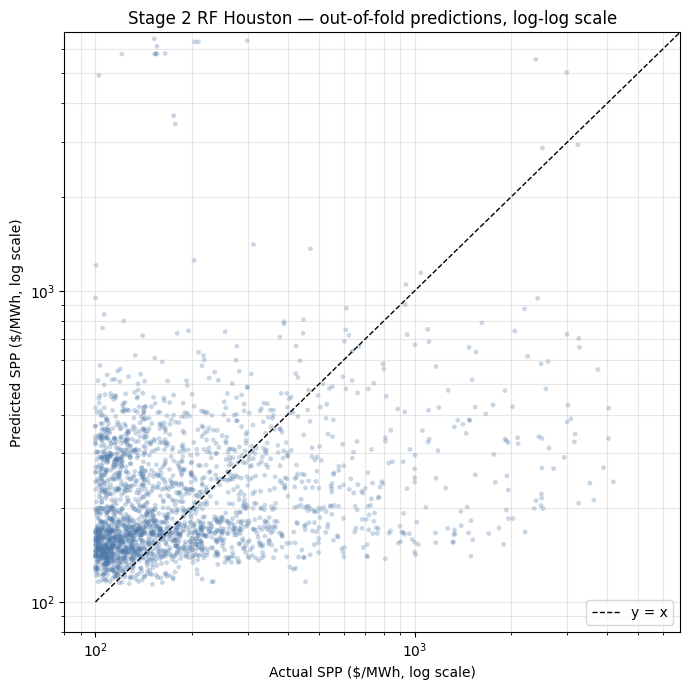

Dollar-scale MAE: $209.18  |  Median |error|: $67.63


In [13]:
rf_pred_h = np.load(H_OUT / 'rf_best_predictions.npz')
y_true = np.exp(rf_pred_h['y_true_log'])
y_pred = np.exp(rf_pred_h['y_pred_log'])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true, y_pred, alpha=0.3, s=12, color='#4c78a8', edgecolor='none')
lo, hi = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max())) * 1.05
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(80, hi); ax.set_ylim(80, hi)
ax.set_xlabel('Actual SPP ($/MWh, log scale)')
ax.set_ylabel('Predicted SPP ($/MWh, log scale)')
ax.set_title('Stage 2 RF Houston — out-of-fold predictions, log-log scale')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

mae = float(mean_absolute_error(y_true, y_pred))
print(f'Dollar-scale MAE: ${mae:.2f}  |  Median |error|: ${float(np.median(np.abs(y_true - y_pred))):.2f}')

You can see the model **systematically underpredicts** as actual SPP rises — the cloud sits below the y=x line in the upper-right corner. Stage 2 is leaf-averaging predictions and the leaves don't go high enough to chase real $5k+ events. The dense cluster near $200-$300 is where most spike rows live, and there the model is well-centered.

## 9. Multi-hub vs Houston-only

For most metrics, multi-hub wins (notably median dollar error: $46 vs $68). Reasons this works at Stage 2 where it didn't at Stage 1 (notebook 05):

1. **4× rows on a 19-feature problem with high variance** — the bias-variance tradeoff genuinely favors more data here. Stage 1's 252k binary classification was already saturating.
2. **The conditional log-magnitude distribution is more similar across hubs** than the binary spike outcome. Once a hub has spiked, the magnitude depends mostly on shared seasonal/gas drivers regardless of which hub.

Location dummies in the multi-hub HGB carry ~0% permutation importance (`loc_HB_PAN`, `loc_HB_SOUTH`, `loc_HB_NORTH` all ≤ 0.01), confirming the model isn't fitting hub-specific noise.

## 10. Recommended deployment

For composing with Stage 1 (see `notebooks/08_combined_evaluation.ipynb`), the recommended Stage 2 model is **multi-hub HGB (`lr=0.05, max_iter=200`)**: lowest median dollar error ($46), comparable RMSE_log to RF, and the location-dummy importance ≈ 0 confirms it's not hub-specific.

The Houston-only RF is a reasonable runner-up if simplicity matters or single-hub interpretability is preferred.

## 11. Limitations (what would actually move the metrics)

- **Negative R² everywhere.** Even the best model is worse than predicting the conditional mean on RMSE_log because the spike subset is highly non-stationary across CV folds (early-2022 spikes look nothing like 2025-26 spikes). Notebook 05 shows that the Uri ablation roughly closes this gap: removing Uri brings RF's R² from −0.42 to −0.05.
- **Top-decile MAE is the binding constraint.** Nothing in this ladder cracks it. Productive next features: **lagged SPP** (1h, 24h, 168h), reserve-margin / ORDC adders, ERCOT load-forecast-vs-realization gap. These are exactly what an operator would look at on a high-spike day — and they're exactly what `08_combined_evaluation.ipynb` found 24h-persistence exploits to beat the model on MAE.
- **Right tail truncation.** Without Uri the model never sees prices above ~$5k. Including Uri lets it see $8,995 but at the cost of distorting the fit on the rest of the distribution. Either choice is a compromise; pick based on operational use case.